In [1]:
import matplotlib.pyplot as plt

import numpy as np
import scipy.signal as sig
import scipy.stats as st

import noisefinder as nf

%matplotlib ipympl

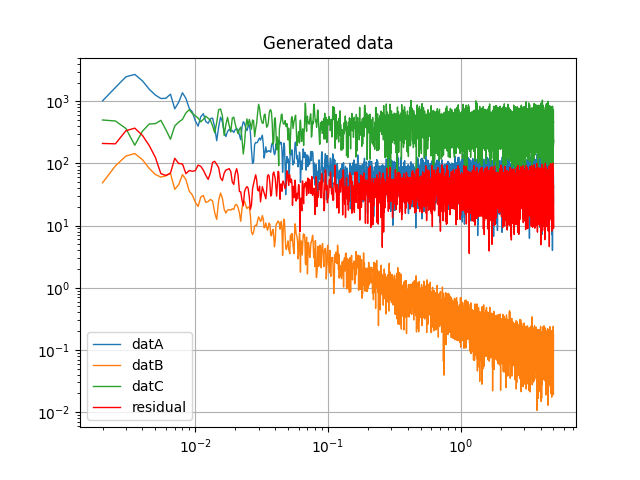

In [2]:
# just generate some data. make them correlated so that we test the entire method.
Ltot = 30000
datres = np.cumsum(st.norm.rvs(size=Ltot))+100*st.norm.rvs(size=Ltot)
datB = 0.5*np.cumsum(st.norm.rvs(size=Ltot))
datC = 1000*st.norm.rvs(size=Ltot)
datA = datres+19*datB+0.10*datC

datres_true = lambda f: np.sqrt((1*10*np.sqrt(2/10)/(2*np.pi*f))**2 + (100*np.sqrt(2/10)*f**0)**2)
datB_true = lambda f: 0.5*10*np.sqrt(2/10)/(2*np.pi*f)
datC_true = lambda f: 1000*np.sqrt(2/10)*f**0
datA_true = lambda f: np.sqrt((datres_true(f))**2 + (19*datB_true(f))**2 + (0.10*datC_true(f))**2)
meas = [datA,datB,datC]

#calculate welch for comparison
PSDfres,PSDvres = sig.welch(datres,fs=10,window=nf.specwindows.BH92(20000),nperseg=20000)
PSDfA,PSDvA = sig.welch(datA,fs=10,window=nf.specwindows.BH92(20000),nperseg=20000,detrend=False)
PSDfB,PSDvB = sig.welch(datB,fs=10,window=nf.specwindows.BH92(20000),nperseg=20000)
PSDfC,PSDvC = sig.welch(datC,fs=10,window=nf.specwindows.BH92(20000),nperseg=20000)

fig,ax=plt.subplots()
ax.loglog(PSDfA[4:],np.sqrt(PSDvA[4:]),lw=1,label='datA')
ax.loglog(PSDfB[4:],np.sqrt(PSDvB[4:]),lw=1,label='datB')
ax.loglog(PSDfC[4:],np.sqrt(PSDvC[4:]),lw=1,label='datC')
ax.loglog(PSDfres[4:],np.sqrt(PSDvres[4:]),lw=1,c='r',label='residual')
ax.grid()
ax.legend()
ax.set_title('Generated data')
plt.show()

In [3]:
#calculate with WOSA method
WOSAfrscheme = nf.freqscheme_presets.wosaScheme(nperseg=20000,win=nf.specwindows.BH92,fs=10)
CPSDresult  = nf.cpsd.CPSDevaluate(ts=meas,freqscheme=WOSAfrscheme)

#extract parameters
print(CPSDresult.cohere)
print(CPSDresult.CPSD)
print(CPSDresult.PSD)
print(CPSDresult.freqs)
print(CPSDresult.Ls)
print(CPSDresult.matp)
print(CPSDresult.navs)
print(CPSDresult.win)

[[[ 1.        +0.j          0.99129459+0.j
    0.85880372+0.j        ]
  [ 0.99129459+0.j          1.        +0.j
    0.78387612+0.j        ]
  [ 0.85880372+0.j          0.78387612+0.j
    1.        +0.j        ]]

 [[ 1.        +0.j          0.99261241+0.02611782j
    0.90247406+0.03110609j]
  [ 0.99261241-0.02611782j  1.        +0.j
    0.84593707+0.01204104j]
  [ 0.90247406-0.03110609j  0.84593707-0.01204104j
    1.        +0.j        ]]

 [[ 1.        +0.j          0.99569848+0.04970869j
    0.19718537-0.52722241j]
  [ 0.99569848-0.04970869j  1.        +0.j
    0.16084243-0.47080121j]
  [ 0.19718537+0.52722241j  0.16084243+0.47080121j
    1.        +0.j        ]]

 ...

 [[ 1.        +0.j         -0.62130483+0.16453056j
    0.50668724-0.80571329j]
  [-0.62130483-0.16453056j  1.        +0.j
   -0.66954274+0.49381007j]
  [ 0.50668724+0.80571329j -0.66954274-0.49381007j
    1.        +0.j        ]]

 [[ 1.        +0.j          0.04213052+0.85418535j
    0.75763885-0.63796951j]
  [ 0.0

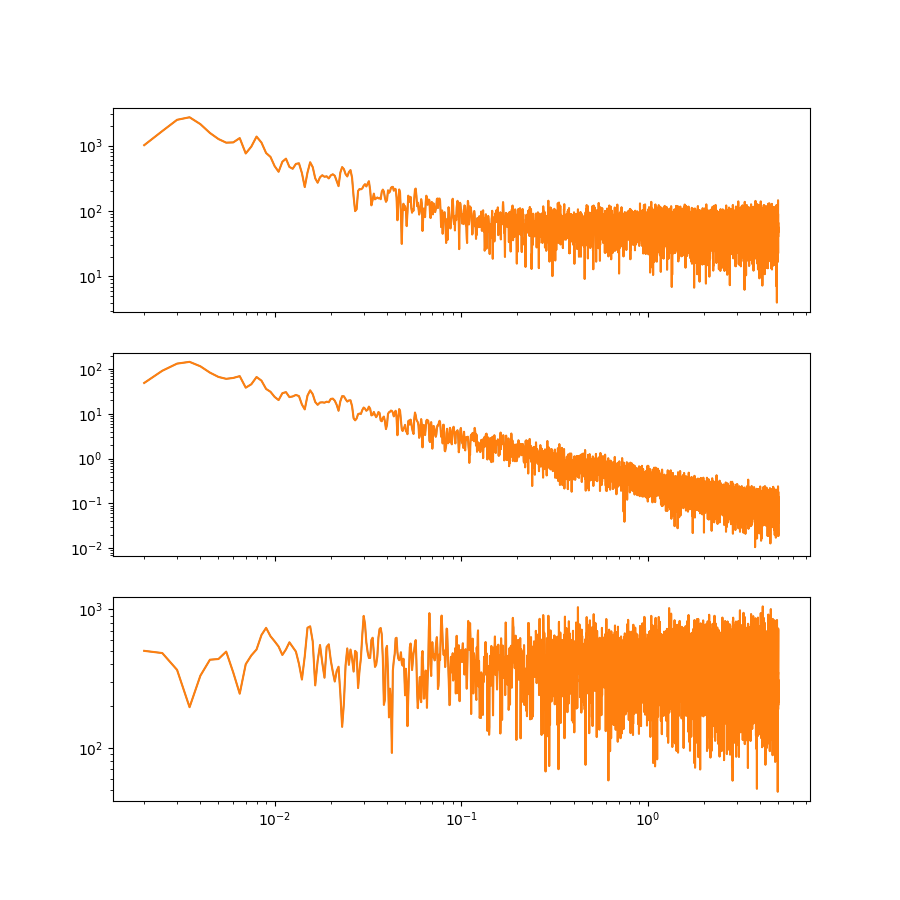

In [4]:

fig,ax=plt.subplots(3,1,figsize=(9,9),sharex=True)
ax[0].loglog(CPSDresult.freqs[4:],np.sqrt(CPSDresult.PSD[0][4:]),lw=1)
ax[0].loglog(PSDfA[4:],np.sqrt(PSDvA[4:]))

ax[1].loglog(CPSDresult.freqs[4:],np.sqrt(CPSDresult.PSD[1][4:]),lw=1)
ax[1].loglog(PSDfB[4:],np.sqrt(PSDvB[4:]))

ax[2].loglog(CPSDresult.freqs[4:],np.sqrt(CPSDresult.PSD[2][4:]),lw=1)
ax[2].loglog(PSDfC[4:],np.sqrt(PSDvC[4:]))

plt.show()
fig.tight_layout()

In [5]:
PSDf,CSDvAB = sig.csd(datA,datB,fs=10,window=nf.specwindows.BH92(20000),nperseg=20000)
PSDf,CSDvBC = sig.csd(datB,datC,fs=10,window=nf.specwindows.BH92(20000),nperseg=20000)
PSDf,CSDvAC = sig.csd(datA,datC,fs=10,window=nf.specwindows.BH92(20000),nperseg=20000)